In [4]:
import numpy as np
import pandas as pd

# =========================================================
# 1. Helper functions
# =========================================================

def make_sigma(p, rho):
    Sigma = np.zeros((p, p))
    for j in range(p):
        for k in range(p):
            Sigma[j, k] = rho ** abs(j - k)
    return Sigma

def true_tree_function(X):
    """
    Piecewise-constant tree regression function.
    Uses X1, X2, X3 only; X4 and X5 are noise features.
    Input:
        X : ndarray of shape (n, p)
    Output:
        f_true : ndarray of shape (n,)
    """
    n = X.shape[0]
    f_true = np.zeros(n)

    # root split on X1
    left = X[:, 0] <= 0
    right = ~left

    # left branch: split on X2
    left_low = left & (X[:, 1] <= 0)
    left_high = left & (X[:, 1] > 0)

    # right branch: split on X3
    right_low = right & (X[:, 2] <= 0.5)
    right_high = right & (X[:, 2] > 0.5)

    f_true[left_low] = 4.0
    f_true[left_high] = 1.0
    f_true[right_low] = -2.0
    f_true[right_high] = 3.0

    return f_true

# =========================================================
# 2. Simulation settings
# =========================================================

n = 500
n_reps = 100
p = 5
rho = 0.0
sigma_eps = 1.0

feature_names = [f"X{j+1}" for j in range(p)]
mu = np.zeros(p)
Sigma = make_sigma(p, rho)

# =========================================================
# 3. Fix the design matrix once
# =========================================================

rng = np.random.default_rng(123)
X = rng.multivariate_normal(mean=mu, cov=Sigma, size=n)
X_df = pd.DataFrame(X, columns=feature_names)

# true tree signal (fixed across replications)
f_true = true_tree_function(X)

# =========================================================
# 4. Generate responses over 100 replications
# =========================================================

y_reps = np.zeros((n_reps, n))

for rep in range(n_reps):
    rng_rep = np.random.default_rng(1000 + rep)
    eps = rng_rep.normal(loc=0.0, scale=sigma_eps, size=n)

    # only the noise changes across replications
    y_reps[rep, :] = f_true + eps

# =========================================================
# 5. Example checks
# =========================================================

print("X shape:", X.shape)
print("Fixed true tree signal shape:", f_true.shape)
print("Response matrix over replications shape:", y_reps.shape)

print("\nFirst 5 rows of X:")
print(X_df.head())

print("\nFirst 10 values of fixed tree signal:")
print(f_true[:10])

print("\nFirst 10 responses in replication 1:")
print(y_reps[0, :10])

X shape: (500, 5)
Fixed true tree signal shape: (500,)
Response matrix over replications shape: (100, 500)

First 5 rows of X:
         X1        X2        X3        X4        X5
0 -0.989121 -0.367787  1.287925  0.193974  0.920231
1  0.577104 -0.636464  0.541952 -0.316595 -0.322389
2  0.097167 -1.525930  1.192166 -0.671090  1.000269
3  0.136321  1.532033 -0.659969 -0.311795  0.337769
4 -2.207471  0.827921  1.541630  1.126807  0.754770

First 10 values of fixed tree signal:
[ 4.  3.  3. -2.  1.  1.  4.  3.  3.  4.]

First 10 responses in replication 1:
[ 3.67866979  2.51433852  4.68005813 -0.02947312  1.15518366 -0.25776545
  4.20021842  3.04205299  2.12198353  5.5294079 ]


In [20]:
import numpy as np
import pandas as pd
import shap
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from itertools import combinations
from math import factorial

# =========================================================
# 1. Helper functions
# =========================================================

def make_sigma(p, rho):
    Sigma = np.zeros((p, p))
    for j in range(p):
        for k in range(p):
            Sigma[j, k] = rho ** abs(j - k)
    return Sigma

def true_tree_function(X):
    """
    True tree regression function.
    Uses X1, X2, X3 only; X4 and X5 are noise features.
    """
    n = X.shape[0]
    f_true = np.zeros(n)

    left = X[:, 0] <= 0
    right = ~left

    left_low = left & (X[:, 1] <= 0)
    left_high = left & (X[:, 1] > 0)

    right_low = right & (X[:, 2] <= 0.5)
    right_high = right & (X[:, 2] > 0.5)

    f_true[left_low] = 4.0
    f_true[left_high] = 1.0
    f_true[right_low] = -2.0
    f_true[right_high] = 3.0

    return f_true

# =========================================================
# 2. Simulation settings
# =========================================================

n = 500
n_reps = 100
p = 5
rho = 0.0
sigma_eps = 1.0

feature_names = [f"X{j+1}" for j in range(p)]
mu = np.zeros(p)
Sigma = make_sigma(p, rho)

# storage
shap_store = np.zeros((n_reps, n, p))
base_store = np.zeros((n_reps, n))

# optional: store X and y if you want later summaries
X_store = np.zeros((n_reps, n, p))
y_store = np.zeros((n_reps, n))

# =========================================================
# 3. Main loop: generate X and y in each replication, then fit
# =========================================================
rng = np.random.default_rng(123)
X = rng.multivariate_normal(mean=mu, cov=Sigma, size=n)
X_df = pd.DataFrame(X, columns=feature_names)

# true tree signal (fixed across replications)
f_true = true_tree_function(X)
for rep in range(n_reps):
    rng_rep = np.random.default_rng(1000 + rep)

    # generate X in each replication
    #X = rng_rep.multivariate_normal(mean=mu, cov=Sigma, size=n)
    #X_df = pd.DataFrame(X, columns=feature_names)

    # generate y from the true tree model
    #f_true = true_tree_function(X)
    eps = rng_rep.normal(loc=0.0, scale=sigma_eps, size=n)
    y = f_true + eps

    # save if needed
    X_store[rep, :, :] = X
    y_store[rep, :] = y

    # fit a tree model
    model = LinearRegression()
    model.fit(X_df, y)

    # compute SHAP values
    explainer = shap.Explainer(model, X_df)
    shap_values = explainer(X_df)

    shap_store[rep, :, :] = shap_values.values
    
    base_vals = np.atleast_1d(shap_values.base_values)
    if len(base_vals) == 1:
        base_store[rep, :] = base_vals[0]
    else:
        base_store[rep, :] = base_vals

# =========================================================
# 4. Average SHAP over replications
# =========================================================

avg_shap = shap_store.mean(axis=0)
sd_shap = shap_store.std(axis=0, ddof=1)
avg_base = base_store.mean(axis=0)   # shape (500,)

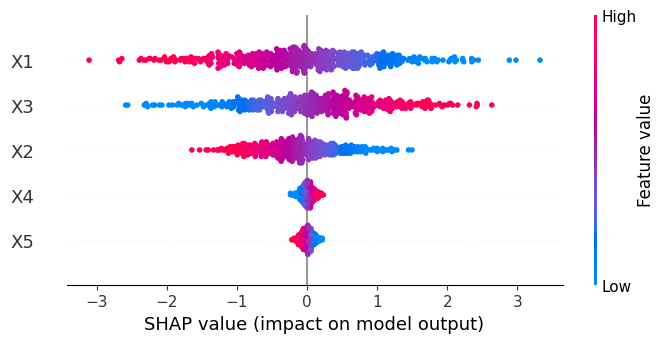

In [22]:
# build SHAP explanation object
avg_explanation = shap.Explanation(
    values=avg_shap,
    base_values=avg_base,
    data=X_df.values,
    feature_names=feature_names
)

# =========================================================
# 6. Beeswarm plot
# =========================================================

#plt.figure(figsize=(8, 5))
#shap.plots.beeswarm(avg_explanation, max_display=p)
#plt.tight_layout()
#plt.savefig("beeswarm_plot_linear1.png", dpi=600, bbox_inches="tight")
#plt.show()
#shap.plots.beeswarm(avg_explanation, max_display=p)
#plt.savefig("beeswarm_plot_linear1.pdf", bbox_inches="tight")
shap.plots.beeswarm(avg_explanation, max_display=p, show=False)
fig = plt.gcf()
fig.savefig("beeswarm_plot_tree1.pdf", bbox_inches="tight")
plt.show()

In [17]:
rng = np.random.default_rng(123)
X = rng.multivariate_normal(mean=mu, cov=Sigma, size=n)
X_df = pd.DataFrame(X, columns=feature_names)

# true tree signal (fixed across replications)
f_true = true_tree_function(X)

for rep in range(n_reps):
    rng_rep = np.random.default_rng(1000 + rep)

    # generate X in each replication
    #X = rng_rep.multivariate_normal(mean=mu, cov=Sigma, size=n)
    #X_df = pd.DataFrame(X, columns=feature_names)

    # generate y from the true tree model
    #f_true = true_tree_function(X)
    eps = rng_rep.normal(loc=0.0, scale=sigma_eps, size=n)
    y = f_true + eps

    # save if needed
    X_store[rep, :, :] = X
    y_store[rep, :] = y

    # fit a tree model
    model = DecisionTreeRegressor(max_depth=2, random_state=123)
    model.fit(X_df, y)

    # compute SHAP values
    explainer = shap.Explainer(model, X_df)
    shap_values = explainer(X_df)

    shap_store[rep, :, :] = shap_values.values
    
    base_vals = np.atleast_1d(shap_values.base_values)
    if len(base_vals) == 1:
        base_store[rep, :] = base_vals[0]
    else:
        base_store[rep, :] = base_vals

# =========================================================
# 4. Average SHAP over replications
# =========================================================

avg_shap = shap_store.mean(axis=0)
sd_shap = shap_store.std(axis=0, ddof=1)
avg_base = base_store.mean(axis=0)   # shape (500,)

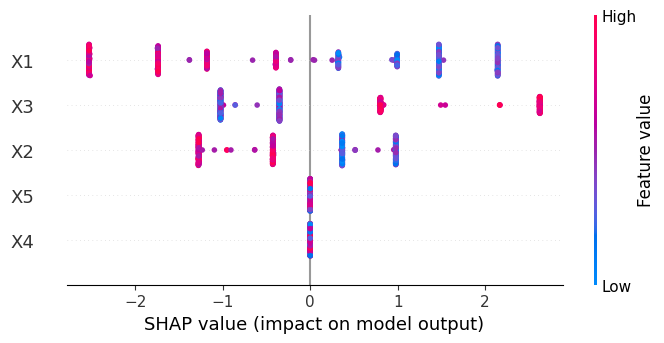

In [18]:
# build SHAP explanation object
avg_explanation = shap.Explanation(
    values=avg_shap,
    base_values=avg_base,
    data=X_df.values,
    feature_names=feature_names
)

# =========================================================
# 6. Beeswarm plot
# =========================================================

#plt.figure(figsize=(8, 5))
#shap.plots.beeswarm(avg_explanation, max_display=p)
#plt.tight_layout()
#plt.savefig("beeswarm_plot_linear1.png", dpi=600, bbox_inches="tight")
#plt.show()
#shap.plots.beeswarm(avg_explanation, max_display=p)
#plt.savefig("beeswarm_plot_linear1.pdf", bbox_inches="tight")
shap.plots.beeswarm(avg_explanation, max_display=p, show=False)
fig = plt.gcf()
fig.savefig("beeswarm_plot_tree_tree_1.pdf", bbox_inches="tight")
plt.show()